# Individual Assignment 1
Student name: Luc Greiner

# Instructions

This course uses Python as a programming language. Don't worry, you will not feel constricted!
If you are not familiar with Python, or with programming in general, have a look at some [tutorials](https://wiki.python.org/moin/BeginnersGuide/NonProgrammers). To untangle your life, we suggets that you run this notebook using [Google Colab](https://colab.research.google.com). If you are not familiar with this environment, please have a look at a [tutorial](https://colab.research.google.com). However, you can always run this code locally, either as a notebook or copy the code into a plain script. You just have to make sure you can run python code and have the necessary dependencies installed.

Feel free to play around with the code and all available functionality!


# Install packages

First we install the required external python packages. In this notebook we will make use of [OpenCV](https://github.com/opencv/opencv-python), so we install it using pip (the standard python dependency manager).

In [11]:
#!pip install -q --upgrade pip
#!pip install opencv-python numpy moviepy

# File paths

For this project, I use Google Drive for video storage. All files are read and written to my personal Google Drive space.

In [12]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Add paths to folder for video input and output

In [13]:
# List files in relevant directory
import os
print(os.listdir('/content/drive/MyDrive/Cours KU/S2/Computer Vision/Project/Individual assignment 1'))

folder = '/content/drive/MyDrive/Cours KU/S2/Computer Vision/Project/Individual assignment 1/'

# Add paths to file
original_video = folder + 'PXL_20260219_212014081.mp4'
downsized_video = folder + 'downsized_video.mp4'
processed_video = folder + 'processed_video.mp4'
compressed_video = folder + 'compressed_video.mp4'

# Paths to export templates (for visual check)
template_body_png = folder + 'template_body.png'
template_eyes_png = folder + 'template_eyes.png'

['PXL_20260219_212014081.mp4', 'downsized_video.mp4', 'archive', 'compressed_video.mp4', 'template_body.png', 'template_eyes.png', 'processed_video.mp4', 'CV_IA1.pdf', 'submission']


# Downsize video

We reduce our video resolution as the current video exceeds the maximum allowed size. This will speed up video editing.

In [14]:
if True: # set to False to exclude execution (code only needs to be run once)

  import cv2

  def downsize_video(input_path, output_path, scale_percent=50, target_width=None, target_height=None):
      """
      Reads a video and saves a downsized version.

      Args:
          input_path (str): Path to source video.
          output_path (str): Path to save the resized video.
          scale_percent (int): Percentage of original size (if target dims are None).
          target_width (int): Specific width (optional).
          target_height (int): Specific height (optional).
      """
      # Open the source video
      cap = cv2.VideoCapture(input_path)

      if not cap.isOpened():
          print("Error: Could not open video.")
          return

      # Get original video properties
      orig_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
      orig_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
      fps = cap.get(cv2.CAP_PROP_FPS)

      # Calculate new dimensions
      if target_width and target_height:
          new_width, new_height = target_width, target_height
      else:
          new_width = int(orig_width * scale_percent / 100)
          new_height = int(orig_height * scale_percent / 100)

      print(f"Original: {orig_width}x{orig_height} @ {fps} FPS")
      print(f"Downsizing to: {new_width}x{new_height}")

      # Define the codec and create VideoWriter object
      fourcc = cv2.VideoWriter_fourcc(*'mp4v')
      out = cv2.VideoWriter(output_path, fourcc, fps, (new_width, new_height))

      # Process frame-by-frame
      while True:
          ret, frame = cap.read()
          if not ret:
              break  # End of video

          # Resize the frame (using cv2.INTER_AREA for shrinking)
          resized_frame = cv2.resize(frame, (new_width, new_height), interpolation=cv2.INTER_AREA)

          # Write the resized frame
          out.write(resized_frame)

      # Release resources
      cap.release()
      out.release()
      print(f"Success! Downsized video saved to: {output_path}")

  downsize_video(original_video, downsized_video, scale_percent=50)

Original: 1920x1080 @ 29.998879732784076 FPS
Downsizing to: 960x540
Success! Downsized video saved to: /content/drive/MyDrive/Cours KU/S2/Computer Vision/Project/Individual assignment 1/downsized_video.mp4


# Import packages

Now we can import the necessary packages into our python workspace. OpenCV provides the package cv2 which contains handy functionality to handle images and videos.

In [15]:
import argparse
import cv2
import sys
import numpy as np
from datetime import datetime

from google.colab.patches import cv2_imshow

# Video editing

## Video editing functions

In [16]:

"""
  TODO: Define additional functions here with the requested functionality.
"""

#------------------------------------------------------------------------------#
# Common functions
#------------------------------------------------------------------------------#

def colour_to_gray(frame):
  """
  Convert 3-channel BGR to 1-channel grayscale
  """
  return cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

def gray_to_colour(frame):
  """
  Convert 1-channel grayscale to 3-channel BGR
  """
  return cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)

#------------------------------------------------------------------------------#
# Basic image processing: 0 - 20s
#------------------------------------------------------------------------------#

def gaussian_blur(frame, kernel_size=15, sigma=0):
    """
    Applies a Gaussian Blur.
    The width/height of the blur kernel must be an odd number.
    """
    # Ensure kernel_size is odd (required by OpenCV)
    if kernel_size % 2 == 0:
        kernel_size += 1

    # sigma = 0 tells OpenCV to calculate sigma based on the kernel size
    return cv2.GaussianBlur(frame, (kernel_size, kernel_size), sigma)


def bilateral_filter(frame, d=9, sigma_color=75, sigma_space=75):
    """
    Applies a Bilateral Filter: Unlike Gaussian blur, it preserves edges while smoothing.

    Args:
        d (int): Diameter of each pixel neighbourhood.
        sigma_color (float): Filter sigma in the colour space.
        sigma_space (float): Filter sigma in the coordinate space.
    """
    return cv2.bilateralFilter(frame, d, sigma_color, sigma_space)


def segment_rgb(frame, lower, upper):
    """
    Segments the object using RGB color space.
    Args:
        lower: a 3D numpy array of lower RGB values
        upper: a 3D numpy array of upper RGB values
    """
    return cv2.inRange(frame, lower, upper) # return mask


def segment_hsv(frame, lower, upper):
    """
    Segments the object using HSV color space.
        Args:
        lower: a 3D numpy array of lower RGB values
        upper: a 3D numpy array of upper RGB values
    """
    # Convert to HSV then return mask
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    return cv2.inRange(hsv, lower, upper)


def apply_morphology(mask):
    """Removes noise and fills holes in a binary mask using opening and closing."""
    # Create a rectangle kernel
    kernel = np.ones((5, 5), np.uint8) # 5 is a midrange value

    # Remove small white noise (Erosion then Dilation)
    opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    # Erosion: A pixel is kept white only if all pixels under the kernel are white.
    # Dilation: A pixel is turned white if at least one pixel under the kernel is white.

    # Fill small black holes (Dilation then Erosion)
    return cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)


def highlight_improvements(raw_mask, refined_mask):
    """
    Creates a BGR image where:
    - White: The mask where no improvements were made
    - Green: Pixels added to fill holes (improvement)
    - Red: Pixels removed as noise (improvement)
    """
    # Create a base 3-channel image from the refined mask (white/black)
    display = gray_to_colour(refined_mask)

    # Identify pixels added
    added = cv2.subtract(refined_mask, raw_mask)

    # Identify pixels removed
    removed = cv2.subtract(raw_mask, refined_mask)

    # Colour added pixels = Green (B, G, R)
    display[added > 0] = [0, 255, 0]
    # Colour removed pixels = Red (B, G, R)
    display[removed > 0] = [0, 0, 255]

    return display

#------------------------------------------------------------------------------#
# Object detection: 20 - 40s
#------------------------------------------------------------------------------#

def sobel_horizontal(frame, kernel):
    """
    Applies a Sobel filter in the horizontal direction.
    """
    # Convert to 1-channel grascale
    frame = colour_to_gray(frame)

    # Run Sobel Filters (dx=1 for Vertical, dy=1 for Horizontal)
    sy = cv2.Sobel(frame, cv2.CV_64F, 0, 1, ksize=kernel)

    # Convert results back to 8-bit image format
    abs_y = cv2.convertScaleAbs(sy)

    # Convert frame to 3-channel BGR (B=G=R)
    return gray_to_colour(abs_y)


def sobel_vertical(frame, kernel):
    """
    Applies a Sobel filter in the vertical direction.
    """
    # Convert to 1-channel grascale
    frame = colour_to_gray(frame)

    # Run Sobel Filters (dx=1 for Vertical, dy=1 for Horizontal)
    sx = cv2.Sobel(frame, cv2.CV_64F, 1, 0, ksize=kernel)

    # Convert results back to 8-bit image format
    abs_x = cv2.convertScaleAbs(sx)

    # Convert to 3-channel BGR (B=G=R)
    return gray_to_colour(abs_x)


def sobel_handv(frame, kernel):
    """
    Applies a Sobel filter in the horizontal and vertical direction.
    """
    # Convert to 1-channel grascale
    frame = colour_to_gray(frame)

    # Run Sobel Filters (dx=1 for Vertical, dy=1 for Horizontal)
    sy = cv2.Sobel(frame, cv2.CV_64F, 0, 1, ksize=kernel)
    sx = cv2.Sobel(frame, cv2.CV_64F, 1, 0, ksize=kernel)

    # Calculate the combined "strength" of the edges
    magnitude = cv2.magnitude(sx, sy)

    # Convert results back to 8-bit image format
    combined = cv2.convertScaleAbs(magnitude)

    # Convert to 3-channel BGR (B=G=R)
    return gray_to_colour(combined)


def canny_edge(frame, low_threshold, high_threshold, blur_ksize):
    """
    Applies Canny Edge Detection.
    """
    # Convert to grayscale
    frame = colour_to_gray(frame)

    # Gaussian Blur to prevent small textures from being detected as edges
    blurred = cv2.GaussianBlur(frame, (blur_ksize, blur_ksize), 0)

    # Canny Algorithm
    return cv2.Canny(blurred, low_threshold, high_threshold) # returns edges


def detect_circles(frame, edge=100, accumulator=30, mind=50, minr=10):
    """
    Detect circles in a BGR frame and draw circles on the output frame.
    """
    # Convert to 1-channel grascale
    grey = colour_to_gray(frame)

    # Smooth the image (using median blur) to prevent false circle detection
    grey = cv2.medianBlur(grey, 5)

    # Apply Hough Circles
    # dp: Inverse ratio of accumulator resolution to image resolution (1 is normal)
    # minDist: Minimum distance between the centers of detected circles
    # param1 (Edge Threshold): Controls how "sharp" a change in brightness must be to be considered an edge pixel.
    # param2 (Accumulator Threshold): Controls how many "votes" a center point needs before the algorithm declares it is a circle.
    circles = cv2.HoughCircles(grey, cv2.HOUGH_GRADIENT, dp=1, minDist=mind,
                               param1=edge, param2=accumulator, minRadius=minr, maxRadius=100)

    if circles is not None:
        # Convert the circle parameters (x, y, radius) to integers
        circles = np.uint16(np.around(circles))
        for i in circles[0, :]:
            # Draw the outer circle (Green)
            cv2.circle(frame, (i[0], i[1]), i[2], (0, 255, 0), 2)
            # Draw the center of the circle (Red)
            cv2.circle(frame, (i[0], i[1]), 2, (0, 0, 255), 3)

    return frame


def create_template(frame, template, export):
    """
    Crop a single frame to create a template
    """
    x, y, w, h = template

    template = frame[y:y+h, x:x+w]

    # Save png for verifications
    success = cv2.imwrite(export, template)
    if success:
        print(f"Successfully saved template to: {export}")
    else:
        print(f"Failed to save template.")

    # Return template
    return template


def template_matching_intensity(frame, template):
    """
    Identify object using template matching and rectangle box.
    """

    # Convert to 1-channel grascale
    template = colour_to_gray(template)
    frame = colour_to_gray(frame)

    # Perform template matching using normalised cross-correlation
    res = cv2.matchTemplate(frame, template, cv2.TM_CCORR_NORMED)

    # Find max intensity value to draw rectangle
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)

    # Normalise to greyscale to match video encoding
    res_map = cv2.normalize(res, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    return res_map, max_loc # res_map used for intensity map and max_loc for rectangle


def template_matching_rectangle(frame, template, max_loc):
  """
  Draw a rectangle box around the macthed object.
  """
  # Get template dimensions
  th, tw = template.shape[:2]

  # Define corners
  top_left = max_loc
  bottom_right = (top_left[0] + tw, top_left[1] + th)

  # Draw the rectangle
  return cv2.rectangle(frame, top_left, bottom_right, (0, 255, 0), 2)

#------------------------------------------------------------------------------#
# Carte blanche: 40 - 60s
#------------------------------------------------------------------------------#

def duplicate_template(frame, template_loc, mask, dest_x, dest_y, scale=1.0):
    """
    Combine a template and a HSV mask to copy the identified object to a new location.
    This function changes the identified object from white to red using the mask.
    The object can be rescaled.
    """

    x, y, w, h = template_loc

    # Extract the original region of interest (ROI) and mask
    roi_original = frame[y:y+h, x:x+w].copy()
    mask_roi = mask[y:y+h, x:x+w].copy()

    # Prepare resizing of the sprite and mask
    new_w, new_h = int(w * scale), int(h * scale)
    new_dim = (new_w, new_h)

    # Resize using linear interpolation
    sprite_resized = cv2.resize(roi_original, new_dim, interpolation=cv2.INTER_LINEAR)
    mask_resized = cv2.resize(mask_roi, new_dim, interpolation=cv2.INTER_NEAREST)

    # Apply the red color to the sprite using the mask to find the template area
    sprite_resized[mask_resized > 0] = [0, 0, 255]

    # Extract the destination ROI using the new dimensions
    roi_destination = frame[dest_y:dest_y+new_h, dest_x:dest_x+new_w]

    # Prepare the background with the resized inverse mask
    mask_inv = cv2.bitwise_not(mask_resized)

    # Isolate template pixels in the resized sprite
    template_sprite = cv2.bitwise_and(sprite_resized, sprite_resized, mask=mask_resized)

    # Create the hole in the destination
    bg_with_hole = cv2.bitwise_and(roi_destination, roi_destination, mask=mask_inv)

    # Combine and place the sprite at destination location
    combined = cv2.add(bg_with_hole, template_sprite)
    frame[dest_y:dest_y+new_h, dest_x:dest_x+new_w] = combined

    return frame


def superpose_template_on_edges(frame, template_loc, mask,
                            canny_lt=50, canny_ht=150, canny_blur=5):
    """
    Superpose an object (matched using template matching and a mask) on top of a Canny frame.
    This function changes the identified object from white to red using the mask.
    """
    x, y, w, h = template_loc

    # Get the background using Canny edges
    edges = canny_edge(frame, canny_lt, canny_ht, canny_blur)
    edge_background = gray_to_colour(edges)

    # Get the mask for the specific ROI directly from the HSV mask
    roi_mask = mask[y:y+h, x:x+w]

    # Superpose red eyes onto the Canny edge frame
    roi_edges = edge_background[y:y+h, x:x+w]
    roi_edges[roi_mask > 0] = [0, 0, 255] # set to Red

    return edge_background


## Define helper functions

We define a couple of helper functions.

In [17]:
def get_frame_time(cap) -> int:
  # Get the current video frame's timestamp in milliseconds
  return int(cap.get(cv2.CAP_PROP_POS_MSEC))

def between(cap, lower: int, upper: int) -> bool:
    """
    To check whether a frame is between two time points (in milliseconds).
    Args:
        cap: OpenCV video object
        lower: lower bound in milliseconds
        upper: upper bound in milliseconds
    """
    # Compare timeranges in milliseconds
    return lower <= get_frame_time(cap) < upper

# Prepare template matching
template_body = None
template_body_loc = 275, 100, 250, 375 # x, y, w, h (set manually)

template_eyes = None
template_eyes_loc = 385, 200, 125, 60 # x, y, w, h (set manually)

# Subtitle settings
font_name = cv2.FONT_HERSHEY_SIMPLEX
font_position = (20, 50)
font_y_offset = 20
font_colour = (255, 200, 150) # light blue
font_scale = 0.6
font_thickness = 2

## Apply functions to edit video

In [18]:
"""Skeleton code for python script to process a video using OpenCV package

:copyright: (c) 2021, Joeri Nicolaes
:license: BSD license
"""

def main(input_video_file: str, output_video_file: str) -> None:
    # OpenCV video objects to work with
    cap = cv2.VideoCapture(input_video_file)

    if cap is None or not cap.isOpened():
      raise RuntimeError('The file was not found or is not a proper video.')

    # Video settings
    fps = int(round(cap.get(5)))
    frame_width = int(cap.get(3))
    frame_height = int(cap.get(4))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # video codec
    # Create a VideoWriter object to save the processed video to the specified
    #   output_video_file using the defined codec, fps, and frame dimensions:
    out = cv2.VideoWriter(output_video_file, fourcc, fps, (frame_width, frame_height))

    # Process video
    while cap.isOpened():
        # Reads the next frame from the video:
        # - ret is a boolean indicating if the frame was read successfully
        # - frame is the actual image data.
        ret, frame = cap.read()

        if ret:

            """
              TODO: Call the defined functions with the functionality requested in the assignment.
            """

            # Create template for template matching: use 1st frame
            if between(cap, 0, 25): # catch the 1st frame at 30 fps
                # Match body
                template_body = create_template(frame, template_body_loc, template_body_png)

                # Match eyes
                template_eyes = create_template(frame, template_eyes_loc, template_eyes_png)

#------------------------------------------------------------------------------#
# Basic image processing: 0 - 20s
#------------------------------------------------------------------------------#

            # Grayscale
            if between(cap, 1000, 1800) or  between(cap, 3000, 3800):
                frame = colour_to_gray(frame)
                frame = gray_to_colour(frame)

                cv2.putText(frame, "Grayscale: a 3-channel BGR colour frame (O to 255 for each channel) is converted",
                            font_position, font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "to a 1-channel intensity map: 0 (black) to 255 (white)",
                            (font_position[0],font_position[1]+font_y_offset*1), font_name, font_scale, font_colour, font_thickness)


            # Gaussian blur
            if between(cap, 4000, 5800):
                frame = gaussian_blur(frame,5)

                # Add subtitles
                cv2.putText(frame, "Minor Gaussian blur (kernel=5)",
                            font_position, font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> With a small kernel, the blur is limited.",
                            (font_position[0],font_position[1]+font_y_offset*1), font_name, font_scale, font_colour, font_thickness)

            if between(cap, 6000, 7800):
                frame = gaussian_blur(frame,25)

                cv2.putText(frame, "Major Gaussian blur (kernel=25)",
                            font_position, font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> With a large kernel, the blur is strong.",
                            (font_position[0],font_position[1]+font_y_offset*1), font_name, font_scale, font_colour, font_thickness)

            # Bilateral filter
            if between(cap, 8000, 9800):
                frame = bilateral_filter(frame,9,50,50)

                cv2.putText(frame, "Minor bilateral filtering 'BF' (d=9, sigmaColour=50, sigmaSpace=50)",
                            font_position, font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "- d: pixel neighbourhood size used for blur.",
                            (font_position[0],font_position[1]+font_y_offset*1), font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "- sigmaColour: controls how similar colours must be for pixels to be blurred together.",
                            (font_position[0],font_position[1]+font_y_offset*2), font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "- sigmaSpace: controls how closely located must be for pixels to be blurred together.",
                            (font_position[0],font_position[1]+font_y_offset*3), font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> BF with low sigma values leads to a local sharp blur that preserves edges.",
                            (font_position[0],font_position[1]+font_y_offset*4), font_name, font_scale, font_colour, font_thickness)

            if between(cap, 10000, 11800):
                frame = bilateral_filter(frame,9,150,150)

                cv2.putText(frame, "Major bilateral filtering 'BF' (d=9, sigmaColour=150, sigmaSpace=150)",
                            font_position, font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> BF with high sigma values leads to a stronger blur that",
                            (font_position[0],font_position[1]+font_y_offset*1), font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "   still mostly preserves edges compared to Gaussian blur.",
                            (font_position[0],font_position[1]+font_y_offset*2), font_name, font_scale, font_colour, font_thickness)

            # RGB mask
            if between(cap, 12000, 13800):
                # Define RGB thresholds: targets are black areas
                rgb_lower = np.array([0, 0, 0])    # B, G, R
                rgb_upper = np.array([20, 20, 20])

                # Apply mask
                mask_rgb = segment_rgb(frame, rgb_lower, rgb_upper)

                # Convert binary mask to 3-channel BGR
                frame = gray_to_colour(mask_rgb)

                # Add subtitles
                cv2.putText(frame, "Raw RGB Mask: locate black/dark areas (B < 20, G < 20, R < 20)",
                            font_position, font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> Filter RGB pixel values directly, here to locate black/dark areas (low RGB values).",
                            (font_position[0],font_position[1]+font_y_offset*1), font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> Values that match the black/dark area filter are displayed in white.",
                            (font_position[0],font_position[1]+font_y_offset*2), font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "   This filter identifies the black TV, rabbit eyes and the dark areas under the furniture.",
                            (font_position[0],font_position[1]+font_y_offset*3), font_name, font_scale, font_colour, font_thickness)

            # HSV mask
            if between(cap, 14000, 15800):
                # Define HSV thresholds: targets are black areas
                hsv_lower = np.array([0, 0, 0])
                hsv_upper = np.array([180, 255, 60])
                # Hue [0, 180]: select all, meaning ingore the hue
                # Saturation / purity: select all (0 is completely grayscale, 255 is a vivid color.)
                # Value / brigthness: 0 is total darkness, while 255 is the brightest

                # Apply mask
                mask_hsv = segment_hsv(frame, hsv_lower, hsv_upper)

                # Convert binary mask to 3-channel BGR
                frame = gray_to_colour(mask_hsv)

                # Add subtitles
                cv2.putText(frame, "Raw HSV Mask: locate black/dark areas (H <= 180, S <= 255, V <= 60)",
                            font_position, font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "- Hue: select all, meaning ignore hue completely.",
                            (font_position[0],font_position[1]+font_y_offset*1), font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "- Saturation: select all, meaning ignore saturation completely.",
                            (font_position[0],font_position[1]+font_y_offset*2), font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "- Value: select only the smallest value, meaning focus on darkest areas.",
                            (font_position[0],font_position[1]+font_y_offset*3), font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> Values that match the black/dark area filter are displayed in white.",
                            (font_position[0],font_position[1]+font_y_offset*4), font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> Alternative approach to RGB masking which is often more robust to lightning changes.",
                            (font_position[0],font_position[1]+font_y_offset*5), font_name, font_scale, font_colour, font_thickness)


            # HSV mask: Morphological Improvements in Color
            if between(cap, 16000, 19800):
                # Using HSV as the base for improvement since it's usually more robust
                mask = segment_hsv(frame, hsv_lower, hsv_upper)

                # Apply morphology processing and highlight colours
                refined = apply_morphology(mask)
                frame = highlight_improvements(mask, refined)

                # Add subtitles
                cv2.putText(frame, "Improvements for the HSV mask using a rectangle kernel (5,5) and opening/closing operations.",
                            font_position, font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "Green pixels: pixels ADDED to mask after morphological processing.",
                            (font_position[0],font_position[1]+font_y_offset*1), font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "Red pixels: pixels REMOVED from mask after morphological processing.",
                            (font_position[0],font_position[1]+font_y_offset*2), font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> The morphological processing leads to a smoother mask with less noise and holes.",
                            (font_position[0],font_position[1]+font_y_offset*3), font_name, font_scale, font_colour, font_thickness)

#------------------------------------------------------------------------------#
# Object detection: 20 - 40s
#------------------------------------------------------------------------------#

            # Sobel edge detector
            sobel_low, sobel_high = 3, 5
            if between(cap, 20000, 21000):
                frame = sobel_horizontal(frame,sobel_low)

                cv2.putText(frame, f"Sobel horizontal edge detector (kernel size={sobel_low})",
                            font_position, font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> Identify horizontal edges with high sensitivity.",
                            (font_position[0],font_position[1]+font_y_offset*1), font_name, font_scale, font_colour, font_thickness)

            if between(cap, 21200, 22200):
                frame = sobel_horizontal(frame,sobel_low)

                cv2.putText(frame, f"Sobel horizontal edge detector (kernel size={sobel_low})",
                            font_position, font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> Identify horizontal edges with high sensitivity.",
                            (font_position[0],font_position[1]+font_y_offset*1), font_name, font_scale, font_colour, font_thickness)

            if between(cap, 22400, 23400):
                frame = sobel_handv(frame, sobel_low)

                cv2.putText(frame, f"Sobel combined edge detector (kernel size={sobel_low})",
                            font_position, font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> Identify horizontal and vertical edges with high sensitivity.",
                            (font_position[0],font_position[1]+font_y_offset*1), font_name, font_scale, font_colour, font_thickness)

            if between(cap, 23600, 24600):
                frame = sobel_handv(frame, sobel_high)

                cv2.putText(frame, f"Sobel combined edge detector (kernel size={sobel_high})",
                            font_position, font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> Identify horizontal and vertical edges with low sensitivity.",
                            (font_position[0],font_position[1]+font_y_offset*1), font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> Major edges are very bright, but overall result visually worse than smaller kernel.",
                            (font_position[0],font_position[1]+font_y_offset*2), font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> Possible improvement: use threshold to ignore smaller edges/textures.",
                            (font_position[0],font_position[1]+font_y_offset*3), font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> This would hopefully remove the mosaic shapes that are probably due to video compression.",
                            (font_position[0],font_position[1]+font_y_offset*4), font_name, font_scale, font_colour, font_thickness)

            # Hough Circle Transform
            if between(cap, 25000, 26800):
                frame = detect_circles(frame) # default values displayed below

                cv2.putText(frame, "Hough Circle Detection:",
                            font_position, font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "baseline paramaters: edge=100, accumulator=30, minDist=50, minRadius=10, maxRadius=100",
                            (font_position[0],font_position[1]+font_y_offset*1), font_name, font_scale, font_colour, font_thickness)

            if between(cap, 27000, 28800):
                frame = detect_circles(frame, edge=125)

                cv2.putText(frame, "Hough Circle Detection: Higher Edge Threshold (125)",
                            font_position, font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> Only signicant changes in brightness are considered to identify circle edges.",
                            (font_position[0],font_position[1]+font_y_offset*1), font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> Fewer circle shapes detected.",
                            (font_position[0],font_position[1]+font_y_offset*2), font_name, font_scale, font_colour, font_thickness)

            if between(cap, 29000, 30800):
                frame = detect_circles(frame, accumulator=35)

                cv2.putText(frame, "Hough Circle Detection: Higher Accumulator Threshold (35)",
                            font_position, font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> Only circles with a many 'votes' are considered to identify circles.",
                            (font_position[0],font_position[1]+font_y_offset*1), font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> Fewer circle shapes detected.",
                            (font_position[0],font_position[1]+font_y_offset*2), font_name, font_scale, font_colour, font_thickness)

            if between(cap, 31000, 32800):
                frame = detect_circles(frame, mind=100)

                cv2.putText(frame, "Hough Circle Detection: Higher min. distance between circles (100)",
                            font_position, font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> Only circles that are far enough apart are considered to identify circles.",
                            (font_position[0],font_position[1]+font_y_offset*1), font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> Fewer circle shapes detected.",
                            (font_position[0],font_position[1]+font_y_offset*2), font_name, font_scale, font_colour, font_thickness)

            if between(cap, 33000, 34800):
                frame = detect_circles(frame, minr=40)

                cv2.putText(frame, "Hough Circle Detection: Higher min. radius threshold (40)",
                            font_position, font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> Only large enough circles are considered.",
                            (font_position[0],font_position[1]+font_y_offset*1), font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> Fewer circle shapes detected.",
                            (font_position[0],font_position[1]+font_y_offset*2), font_name, font_scale, font_colour, font_thickness)


            # Template matching: draw rectangle
            if between(cap, 35000, 36800):
                _, max_loc = template_matching_intensity(frame, template_body)
                frame = template_matching_rectangle(frame, template_body, max_loc)

                cv2.putText(frame, "Template Match: Draw Rectangle Frame",
                            font_position, font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> Detection based on a crop of the 1st video frame.",
                            (font_position[0],font_position[1]+font_y_offset*1), font_name, font_scale, font_colour, font_thickness)

            # Template matching: intensity map
            if between(cap, 37000, 39800):
                # Map based on template match (white = match, black = no match)
                res, max_loc = template_matching_intensity(frame, template_body)

                # Get the dimensions of the intensity map
                h_res, w_res = res.shape[:2]

                # Get template dimensions to calculate the shift
                th, tw = template_body.shape[:2]

                # Calculate the offset (half the template size)
                shift_x = tw // 2
                shift_y = th // 2

                # Convert to 3-channel BGR
                res_bgr = gray_to_colour(res)

                # Create an ROI on the frame that is shifted by center_x/y
                # It starts at the shift and extends exactly h_res/w_res pixels
                roi = frame[shift_y : shift_y + h_res, shift_x : shift_x + w_res]

                # Blend the ROI and the Intensity Map
                blended_roi = cv2.addWeighted(roi, 0.05, res_bgr, 0.95, 0)

                # Place the blended result back into the original frame
                frame[shift_y : shift_y + h_res, shift_x : shift_x + w_res] = blended_roi

                cv2.putText(frame, "Template Match: Display Intensity Map",
                            (font_position[0],font_position[1]+font_y_offset*0), font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> The Intensity Map is the black/white rectangle in the center.",
                            (font_position[0],font_position[1]+font_y_offset*1), font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "   Its shape depends on the difference between the frame size and the template size.",
                            (font_position[0],font_position[1]+font_y_offset*2), font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> The brightest point corresponds to the best match and the center of the template.",
                            (font_position[0],font_position[1]+font_y_offset*3), font_name, font_scale, font_colour, font_thickness)

#------------------------------------------------------------------------------#
# Carte blanche: 40 - 60s
#------------------------------------------------------------------------------#

            # Modify objects:
            # - identify eyes and turn them red
            # - copy eyes at different scales and locations
            # Objects are modified sequentially and added on top of previous objects
            eyes_end = 51800

            if between(cap, 40000, eyes_end):

                # Create a copy to prevent overwriting
                original_frame = frame.copy()

                # Define thresholds for darkness (eyes/shadows)
                hsv_lower = np.array([0, 0, 0])
                hsv_upper = np.array([180, 255, 50])

                # Create the general mask
                mask_hsv = segment_hsv(frame, hsv_lower, hsv_upper)

                # Eyes under cage
                frame = duplicate_template(
                    original_frame,
                    template_eyes_loc,
                    mask_hsv,
                    dest_x=0,
                    dest_y=300
                )

                # Eyes under TV
                if between(cap, 42000, eyes_end):
                    frame = duplicate_template(
                        original_frame,
                        template_eyes_loc,
                        mask_hsv,
                        dest_x=825,
                        dest_y=325,
                        scale=0.5
                )

                # Eyes under chair
                if between(cap, 44000, eyes_end):
                    frame = duplicate_template(
                        original_frame,
                        template_eyes_loc,
                        mask_hsv,
                        dest_x=650,
                        dest_y=450,
                        scale=0.75
                )

                # Subtitles on multiple lines
                cv2.putText(frame, "1. Monsters under the bed:",
                              font_position, font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> Use a template of the rabbit's eyes to copy the eyes at different locations and scales.",
                              (font_position[0],font_position[1]+font_y_offset*1), font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> This technique combines template matching and HSV masking to turn the eyes red.",
                              (font_position[0],font_position[1]+font_y_offset*2), font_name, font_scale, font_colour, font_thickness)

                # Eyes on rabbit
                if between(cap, 46000, eyes_end):
                    frame = duplicate_template(
                        original_frame,
                        template_eyes_loc,
                        mask_hsv,
                        dest_x=template_eyes_loc[0],
                        dest_y=template_eyes_loc[1]
                    )
                    cv2.putText(frame, "2. Rabbit is infected by the monsters.",
                              (font_position[0],font_position[1]+font_y_offset*3), font_name, font_scale, font_colour, font_thickness)
                    cv2.putText(frame, "-> Rely on the MSV masking part of the technique to turn the eyes red (copy in place).",
                              (font_position[0],font_position[1]+font_y_offset*4), font_name, font_scale, font_colour, font_thickness)

                # Apply canny edges and red eyes at the same time
                if between(cap, 48000, eyes_end):
                    frame = superpose_template_on_edges(frame, template_eyes_loc, mask_hsv,
                                                    canny_lt=0, canny_ht=80, canny_blur=9)

                    cv2.putText(frame, "3. Rabbit turns into a cyborg.",
                              (font_position[0],font_position[1]+font_y_offset*5), font_name, font_scale, font_colour, font_thickness)
                    cv2.putText(frame, "-> Combine Canny edge detection, template matching and HSV masking.",
                              (font_position[0],font_position[1]+font_y_offset*6), font_name, font_scale, font_colour, font_thickness)



            # Setup HSV masking algorithm
            hsv_start = 52000
            hsv_end = 59800

            if between(cap, hsv_start, hsv_end):
              # White Fur: Low saturation, very high brightness
              white_lower = np.array([0, 0, 200])
              white_upper = np.array([180, 30, 255])
              mask_white = segment_hsv(frame, white_lower, white_upper)

              # Cream Fur: Slight yellow/orange hue, low saturation, high brightness
              cream_lower = np.array([10, 5, 150])
              cream_upper = np.array([35, 60, 255])
              mask_cream = segment_hsv(frame, cream_lower, cream_upper)

              # Combine all masks: pixel is kept if it is White or Cream
              combined_mask = cv2.bitwise_or(mask_white, mask_cream)

              # Standard HSV masking algorithm
              if between(cap, 52000, 55800):
                # Convert binary mask to 3-channel BGR
                frame = gray_to_colour(combined_mask)

                cv2.putText(frame, "HSV masking to identify the rabbit using white and cream pixels.",
                                font_position, font_name, font_scale, font_colour, font_thickness)
                cv2.putText(frame, "-> Difficult to separate cream / grey rabbit fur from similar colours.",
                                (font_position[0],font_position[1]+font_y_offset*1), font_name, font_scale, font_colour, font_thickness)

              # Combine HSV masking with template matching
              if between(cap, 56000, 59800):

                  # Create a grayscale for background
                  grey_background = gray_to_colour(colour_to_gray(frame))

                  # Get the location of the rabbit using template matching
                  _, max_loc = template_matching_intensity(frame, template_body)

                  # Coordinates of the detected rabbit
                  # Get template dimensions
                  th, tw = template_body.shape[:2]

                  # Define corners
                  top_left = max_loc
                  bottom_right = (top_left[0] + tw, top_left[1] + th)

                  # Create a spatial filter: a black mask with a white rectangle over the rabbit
                  refined = apply_morphology(combined_mask) # also apply morphological processing
                  spatial_filter = np.zeros_like(refined)
                  cv2.rectangle(spatial_filter, top_left, bottom_right, 255, -1) # -1 fills the rect

                  # Combine: keep the mask only if it is inside the template rectangle
                  rabbit_only_mask = cv2.bitwise_and(combined_mask, spatial_filter)

                  # Use the mask to extract original colors from the frame: keeps pixels where mask is white (255)
                  coloured_rabbit = cv2.bitwise_and(frame, frame, mask=rabbit_only_mask)

                  # Take the grayscale background everywhere the rabbit isn't
                  inverse_mask = cv2.bitwise_not(rabbit_only_mask)
                  background_part = cv2.bitwise_and(grey_background, grey_background, mask=inverse_mask)

                  # Add them together
                  frame = cv2.add(coloured_rabbit, background_part)

                  cv2.putText(frame, "Combine HSV masking with template matching: rabbit in colour vs gray background.",
                                font_position, font_name, font_scale, font_colour, font_thickness)
                  cv2.putText(frame, "-> Prevents identifying pixels of the same colour far from region of interest.",
                                (font_position[0],font_position[1]+font_y_offset*1), font_name, font_scale, font_colour, font_thickness)
                  cv2.putText(frame, "-> But does not help separate the rabbit from surroundings of the same colour.",
                                (font_position[0],font_position[1]+font_y_offset*2), font_name, font_scale, font_colour, font_thickness)
                  cv2.putText(frame, "-> More advanced techniques required.",
                                (font_position[0],font_position[1]+font_y_offset*3), font_name, font_scale, font_colour, font_thickness)

            # Write frame that you processed to output
            out.write(frame)

            # Debugging: display the resulting frame
            if get_frame_time(cap) == SHOW_FRAME_AT:
                cv2_imshow(frame)
                # If the current frame's time (in milliseconds) matches
                # the value of SHOW_FRAME_AT, it will display that specific frame.
                # This is useful for debugging or previewing a particular moment in the video.

        # Break the loop
        else:
            break

    # When everything done, release the video capture and writing object
    cap.release() # free up system resources associated with the input video file
    out.release() #  ensure that the output video file is properly closed and saved

    # Closes all the frames
    cv2.destroyAllWindows() # This closes any OpenCV windows that might have been opened during the process

# Process video and export

Successfully saved template to: /content/drive/MyDrive/Cours KU/S2/Computer Vision/Project/Individual assignment 1/template_body.png
Successfully saved template to: /content/drive/MyDrive/Cours KU/S2/Computer Vision/Project/Individual assignment 1/template_eyes.png


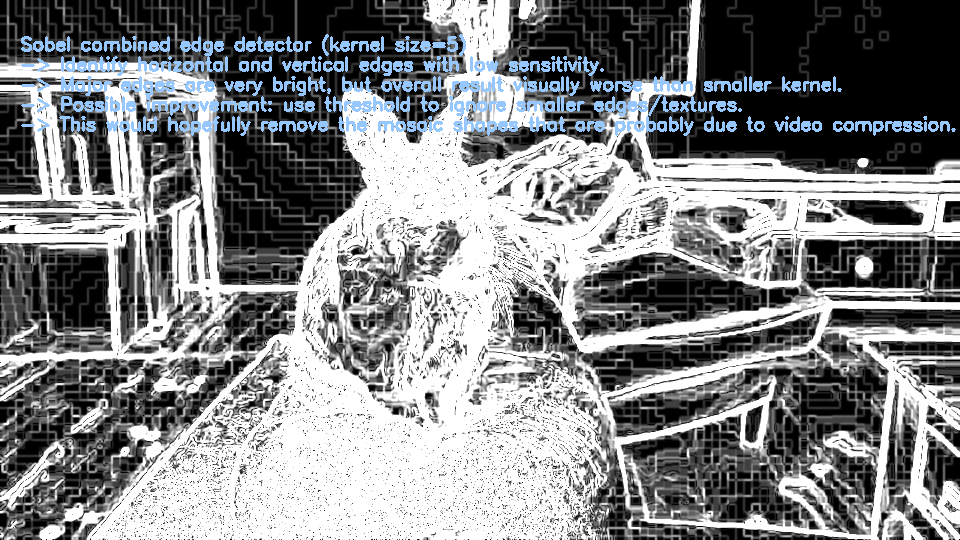

Processing completed at 2026-03-16 20:56:23.357373


In [19]:
# Visualise the corresponding frame
SHOW_FRAME_AT = 24000

# Run video processing and export
main(downsized_video, processed_video)
print("Processing completed at", datetime.now())

# Compress video

Our video editing has increase the video size from 25MB to 40MB. We use MoviePy to compress the video to reduce the size.

In [20]:
if True: # set to False to exclude execution (code only needs to be run once)

  from moviepy.editor import VideoFileClip

  # Load the video file into a MoviePy object
  clip = VideoFileClip(processed_video)

  # Export with specific compression settings
  clip.write_videofile(
      compressed_video,
      bitrate="1500k",      # low bitrate to limit size
      codec="libx264",      # most efficient encoder
      audio=False           # remove audio to limit size
  )

Moviepy - Building video /content/drive/MyDrive/Cours KU/S2/Computer Vision/Project/Individual assignment 1/compressed_video.mp4.
Moviepy - Writing video /content/drive/MyDrive/Cours KU/S2/Computer Vision/Project/Individual assignment 1/compressed_video.mp4



Moviepy - Done !
Moviepy - video ready /content/drive/MyDrive/Cours KU/S2/Computer Vision/Project/Individual assignment 1/compressed_video.mp4
